In [17]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import statistics as st

import functools as ft

import scipy as sc
from scipy.stats import norm
from scipy.signal import welch


import cartopy.crs as ccrs

from eofs.xarray import Eof




In [2]:
path_name = './data/mslp.mon.mean.nc' 
ds = xr.open_dataset(path_name, decode_timedelta=True)

In [3]:
clim = ds.mslp.groupby("time.month").mean("time")
anom = ds.mslp.groupby("time.month") - clim

In [4]:
djf = anom.where(anom.time.dt.month.isin([12,1,2]), drop=True)


In [5]:
winter_year = xr.where(
    djf.time.dt.month == 12,
    djf.time.dt.year + 1,
    djf.time.dt.year
)

In [6]:
djf = djf.assign_coords(winter_year=("time", winter_year.data))


In [7]:
djf = djf.sel(winter_year=slice(1980,2025))

In [8]:
# We are now ready to average the pressure over each winter. 
winter = djf.groupby("winter_year").mean("time")



In [9]:
djf = anom.where(anom.time.dt.month.isin([12,1,2]), drop=True)

# djf are the December, January and February values. Since December 
# of one year belongs to the the winter of the following year we transform this data.

# First creat a DataArray with the "winter year" given the month.  
winter_year = xr.where(
    djf.time.dt.month == 12,
    djf.time.dt.year + 1,
    djf.time.dt.year
)

# winter_year is now a DataArray with the original djf coordinates (time and month) 

# Create a new DataArray from djf with a new coordinate winter_year
djf = djf.assign_coords(winter_year=("time", winter_year.data))

# remove fisrt and last year since they ar enot complete
djf = djf.sel(winter_year=slice(1980,2025))


# We are now ready to average the pressure over each winter. 
winter = djf.groupby("winter_year").mean("time")


# We rename the coordinate to "time" in order to 
winter = winter.rename({"winter_year": "time"})

winter["time"] = np.array(
    [np.datetime64(f"{y}-01-01") for y in winter.time.values]
)

winter_nh = winter.sel(lat=slice(87.5,20))

weights = np.sqrt(np.cos(np.deg2rad(winter_nh.lat)))

weights, _ = xr.broadcast(weights, winter_nh.isel(time=0))

solver = Eof(winter_nh, weights=weights)

In [10]:
eof1 = solver.eofs(neofs=1)

In [11]:
pc1 = solver.pcs(npcs=1, pcscaling=1)

In [12]:
variance = solver.varianceFraction()

print(variance[:5])

<xarray.DataArray 'variance_fractions' (mode: 5)> Size: 20B
array([0.31025946, 0.16155012, 0.10633473, 0.08974855, 0.06511313],
      dtype=float32)
Coordinates:
  * mode     (mode) int64 40B 0 1 2 3 4
Attributes:
    long_name:  variance_fractions


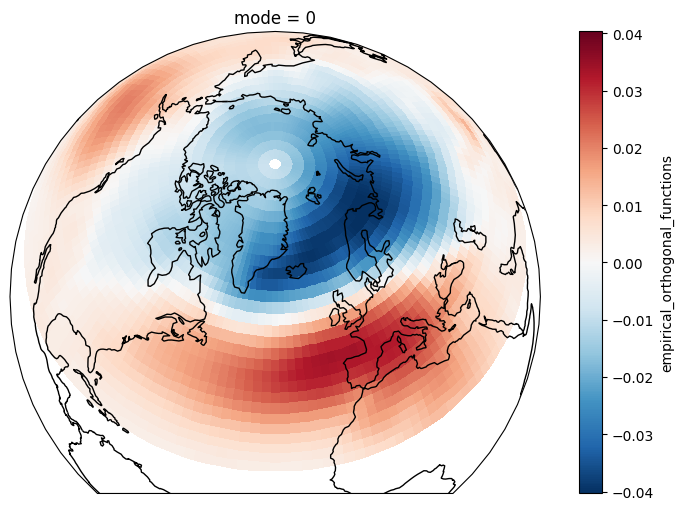

In [13]:
fig = plt.figure(figsize=(10,6))

ax = plt.axes(projection=ccrs.Orthographic(-30, 60))

eof1[0].plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r"
)

ax.coastlines()
plt.savefig('winter-nh-eof.pdf')


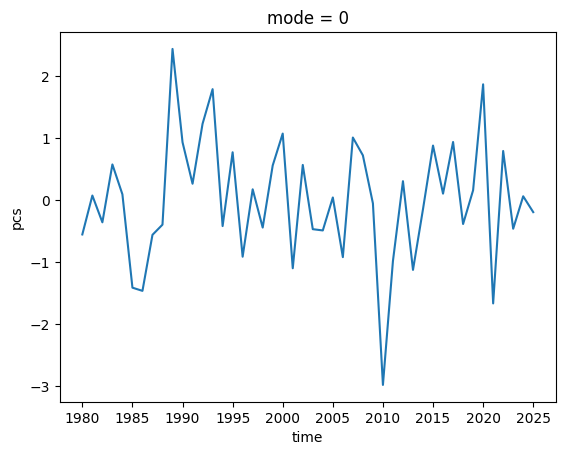

In [14]:
pc1[:,0].plot()
plt.savefig('winter-nh-pc1.pdf')

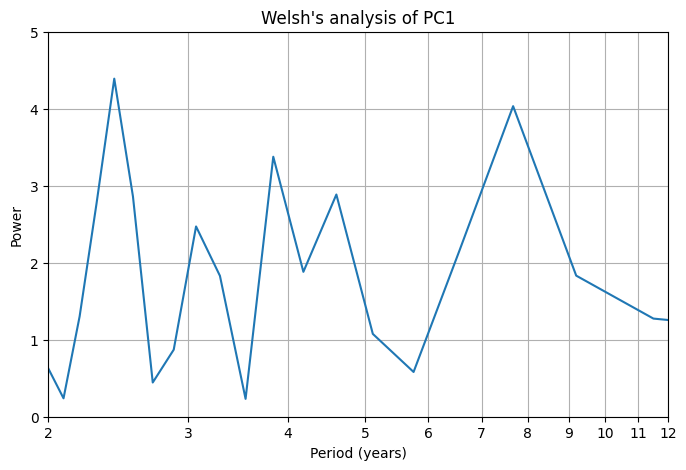

In [15]:
pc = pc1[:,0]
# remove mean
x = pc.values - pc.values.mean()

freq, power = welch(
    x,
    fs=1, # sampling frequency
    nperseg=46,
    detrend='linear'
)


plt.figure(figsize=(8,5))
plt.xlim(2,12)
plt.ylim(0,5)
plt.semilogx(1 / freq[1:], power[1:])   # skip zero frequency
#plt.gca().invert_xaxis()

plt.xlabel("Period (years)")

plt.xticks(ticks=[2, 3, 4, 5, 6,7,8,9,10, 11,12], labels=[2,3,4,5, 6,7,8,9,10,11,12])
plt.ylabel("Power")
plt.title("Welsh's analysis of PC1")
plt.grid()

plt.savefig('pc1-welsh.pdf')
plt.show()


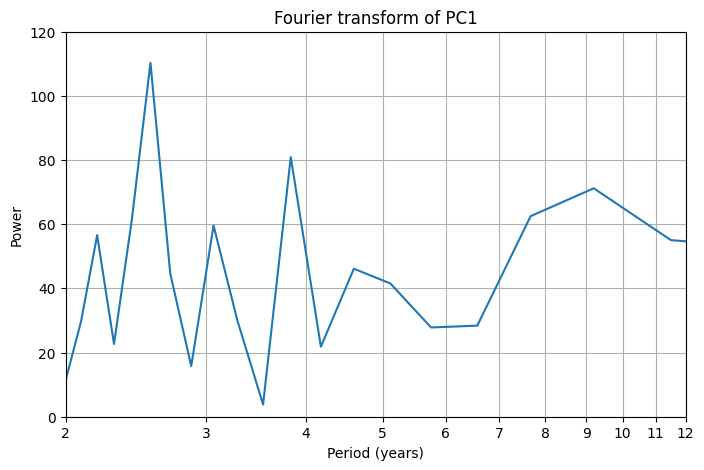

In [16]:
pc = pc1[:,0]
# remove mean
x = pc.values - pc.values.mean()


fft = np.fft.rfft(x)
power = np.abs(fft)**2

freq = np.fft.rfftfreq(len(x), d=1)

plt.figure(figsize=(8,5))
plt.xlim(2,12)
plt.ylim(0,120)
plt.semilogx(1 / freq[1:], power[1:])   # skip zero frequency

plt.xlabel("Period (years)")

plt.xticks(ticks=[2, 3, 4, 5, 6,7,8,9,10,11,12], labels=[2,3,4,5,6,7,8,9,10,11,12])
plt.ylabel("Power")
plt.title("Fourier transform of PC1")
plt.grid()

plt.savefig('pc1-fourier.pdf')
plt.show()